<a href="https://colab.research.google.com/github/2005monicagarcia-arch/PortfolioOptimizationURE26/blob/simple-time-based-split_RF%2BSNN/04_ML_RF%2BSNN__Simple_Time_Based.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving portfolio_option1_EFA_VNQ_20years.csv to portfolio_option1_EFA_VNQ_20years.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [3]:
df = pd.read_csv(
    "portfolio_option1_EFA_VNQ_20years.csv",
    header=[0, 1],
    index_col=0,
    parse_dates=True
)

adj_close = df["Adj Close"]

adj_close.head()

Ticker,AAPL,EFA,IEF,MSFT,NVDA,QQQ,SPY,TLT,VNQ
Date,,,,,,,,,
2006-01-03,2.237673,33.620350,49.090813,18.632084,0.291656,35.273769,87.000908,47.859772,25.824440
2006-01-04,2.244259,33.899529,49.178551,18.722328,0.299822,35.640934,87.412918,47.974487,26.015696
2006-01-05,2.226598,33.729832,49.190231,18.736214,0.306612,35.794636,87.467857,47.917107,26.215464
2006-01-06,2.284073,34.184166,49.125893,18.680685,0.311649,36.443584,88.195740,47.828461,26.461979
2006-01-09,2.276588,34.200577,49.149277,18.645973,0.320348,36.588745,88.422348,47.859772,26.687244


In [4]:
#convert prices to monthly returns
monthly_prices = adj_close.resample("M").last()
monthly_returns = monthly_prices.pct_change().dropna()

monthly_returns.head()

/tmp/ipykernel_734/3807773462.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = adj_close.resample("M").last()


Ticker,AAPL,EFA,IEF,MSFT,NVDA,QQQ,SPY,TLT,VNQ
Date,,,,,,,,,
2006-02-28,-0.092969,-0.007000,-0.001035,-0.042236,0.048264,-0.021429,0.005725,0.011080,0.018579
2006-03-31,-0.084246,0.040052,-0.013579,0.012654,0.214938,0.020910,0.016504,-0.045700,0.047150
2006-04-30,0.122290,0.047905,-0.006271,-0.112459,0.020607,-0.001908,0.012632,-0.027524,-0.034011
2006-05-31,-0.150873,-0.038219,-0.001069,-0.058455,-0.213553,-0.072401,-0.030121,-0.001909,-0.026978
2006-06-30,-0.041828,-0.000611,0.002297,0.028698,-0.073543,-0.000616,0.002608,0.011783,0.049610


In [6]:
#create ML dataset
feature_data = []

for ticker in monthly_returns.columns:
    temp = pd.DataFrame(index=monthly_returns.index)

    temp["ticker"] = ticker

    # Return features
    temp["return_1m"] = monthly_returns[ticker].shift(1)
    temp["return_3m"] = monthly_returns[ticker].rolling(3).sum().shift(1)
    temp["return_6m"] = monthly_returns[ticker].rolling(6).sum().shift(1)

    # Volatility features
    temp["volatility_3m"] = monthly_returns[ticker].rolling(3).std().shift(1)
    temp["volatility_6m"] = monthly_returns[ticker].rolling(6).std().shift(1)

    # Price trend signal
    temp["price"] = monthly_prices[ticker]
    temp["ma_3m"] = monthly_prices[ticker].rolling(3).mean()
    temp["trend_signal"] = (temp["price"] > temp["ma_3m"]).astype(int).shift(1)

    # Target: next-month return direction
    temp["target"] = (monthly_returns[ticker] > 0).astype(int)

    # Actual return for portfolio backtest
    temp["actual_return"] = monthly_returns[ticker]

    feature_data.append(temp)

ml_data = pd.concat(feature_data)
ml_data = ml_data.dropna()
ml_data = ml_data.sort_index()

ml_data.head()

,ticker,return_1m,return_3m,return_6m,volatility_3m,volatility_6m,price,ma_3m,trend_signal,target,actual_return
Date,,,,,,,,,,,
2006-08-31,AAPL,0.186660,-0.006041,-0.060966,0.172253,0.133739,2.031118,1.926644,1.0,0,-0.001619
2006-08-31,MSFT,0.032618,0.002861,-0.139180,0.051487,0.057736,18.037142,17.051359,1.0,1,0.072096
2006-08-31,SPY,0.004478,-0.023035,0.011827,0.019459,0.016586,90.461205,89.041697,1.0,1,0.021822
2006-08-31,IEF,0.016772,0.018001,-0.002885,0.009479,0.010111,49.455647,48.617045,1.0,1,0.017636
2006-08-31,NVDA,0.039926,-0.247169,0.036640,0.126971,0.142363,0.444276,0.369034,1.0,1,0.314815


In [7]:
#define features
features = [
    "return_1m",
    "return_3m",
    "return_6m",
    "volatility_3m",
    "volatility_6m",
    "trend_signal"
]

In [8]:
#simple time-based train/ test split
# Get unique monthly dates
dates = sorted(ml_data.index.unique())

# 80% train, 20% test by time
split_point = int(len(dates) * 0.8)
split_date = dates[split_point]

train_data = ml_data[ml_data.index < split_date]
test_data = ml_data[ml_data.index >= split_date]

X_train = train_data[features]
y_train = train_data["target"]

X_test = test_data[features]
y_test = test_data["target"]

print("Split date:", split_date)
print("Train period:", train_data.index.min(), "to", train_data.index.max())
print("Test period:", test_data.index.min(), "to", test_data.index.max())
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Split date: 2022-07-31 00:00:00
Train period: 2006-08-31 00:00:00 to 2022-06-30 00:00:00
Test period: 2022-07-31 00:00:00 to 2026-06-30 00:00:00
Train size: (1719, 6)
Test size: (432, 6)


In [9]:
#train random forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.5856
              precision    recall  f1-score   support

           0       0.20      0.01      0.02       173
           1       0.59      0.97      0.74       259

    accuracy                           0.59       432
   macro avg       0.40      0.49      0.38       432
weighted avg       0.44      0.59      0.45       432



In [11]:
#train SNN/MLP
mlp_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation="relu",
        alpha=0.001,
        early_stopping=True,
        max_iter=1000,
        random_state=42
    ))
])

mlp_model.fit(X_train, y_train)

mlp_pred = mlp_model.predict(X_test)

print("Neural Network Accuracy:", round(accuracy_score(y_test, mlp_pred), 4))
print(classification_report(y_test, mlp_pred))

Neural Network Accuracy: 0.5856
              precision    recall  f1-score   support

           0       0.38      0.05      0.09       173
           1       0.60      0.94      0.73       259

    accuracy                           0.59       432
   macro avg       0.49      0.50      0.41       432
weighted avg       0.51      0.59      0.48       432



In [12]:
#add predictions to test data
test_data = test_data.copy()

test_data["rf_signal"] = rf_pred
test_data["mlp_signal"] = mlp_pred

test_data.head()

,ticker,return_1m,return_3m,return_6m,volatility_3m,volatility_6m,price,ma_3m,trend_signal,target,actual_return,rf_signal,mlp_signal
Date,,,,,,,,,,,,,
2022-07-31,TLT,-0.012746,-0.129518,-0.239430,0.044495,0.030852,101.047173,99.872899,0.0,1,0.024311,1,1
2022-07-31,IEF,-0.008634,-0.044733,-0.109514,0.024836,0.020033,92.311043,90.801229,0.0,1,0.029615,1,1
2022-07-31,AAPL,-0.081430,-0.233057,-0.245361,0.021562,0.055632,159.311966,146.417475,0.0,1,0.188634,1,1
2022-07-31,MSFT,-0.055321,-0.173265,-0.253960,0.040949,0.046234,271.625244,261.053340,0.0,1,0.093097,1,1
2022-07-31,SPY,-0.082460,-0.167972,-0.212640,0.050514,0.049068,390.533264,379.292196,0.0,1,0.092087,1,0


In [13]:
#build ML portfolio returns
def build_ml_portfolio_returns(data, signal_col):
    portfolio_returns = []

    for date, group in data.groupby(data.index):
        selected_assets = group[group[signal_col] == 1]

        if len(selected_assets) > 0:
            portfolio_return = selected_assets["actual_return"].mean()
            selected_tickers = list(selected_assets["ticker"])
        else:
            portfolio_return = 0
            selected_tickers = []

        portfolio_returns.append({
            "Date": date,
            "Portfolio Return": portfolio_return,
            "Selected Assets": selected_tickers,
            "Number of Assets": len(selected_tickers)
        })

    portfolio_returns = pd.DataFrame(portfolio_returns)
    portfolio_returns = portfolio_returns.set_index("Date")

    return portfolio_returns


In [14]:
rf_portfolio = build_ml_portfolio_returns(test_data, "rf_signal")
mlp_portfolio = build_ml_portfolio_returns(test_data, "mlp_signal")

rf_portfolio.head()

,Portfolio Return,Selected Assets,Number of Assets
Date,,,
2022-07-31,0.086389,"[TLT, IEF, AAPL, MSFT, SPY, QQQ, EFA, VNQ]",8
2022-08-31,-0.062703,"[TLT, AAPL, QQQ, SPY, VNQ, MSFT, EFA, NVDA, IEF]",9
2022-09-30,-0.097335,"[IEF, SPY, VNQ, QQQ, MSFT, AAPL, TLT, EFA]",8
2022-10-31,0.021830,"[IEF, EFA, MSFT, TLT, QQQ, AAPL]",6
2022-11-30,0.081684,"[VNQ, SPY, NVDA, MSFT, TLT, EFA, AAPL, IEF, QQQ]",9


In [15]:
#build benchmark portfolio
test_dates = rf_portfolio.index
test_monthly_returns = monthly_returns.loc[test_dates]

# Buy and Hold SPY
spy_returns = test_monthly_returns["SPY"]

# Equal Weight Portfolio
equal_weight_returns = test_monthly_returns.mean(axis=1)

# 60/40 Portfolio
portfolio_6040_returns = (
    0.60 * test_monthly_returns["SPY"] +
    0.20 * test_monthly_returns["IEF"] +
    0.20 * test_monthly_returns["TLT"]
)

benchmark_returns_split = pd.DataFrame({
    "Buy and Hold SPY": spy_returns,
    "Equal Weight": equal_weight_returns,
    "60/40 Portfolio": portfolio_6040_returns,
    "ML Random Forest": rf_portfolio["Portfolio Return"],
    "ML Neural Network": mlp_portfolio["Portfolio Return"]
})

benchmark_returns_split.head()

,Buy and Hold SPY,Equal Weight,60/40 Portfolio,ML Random Forest,ML Neural Network
Date,,,,,
2022-07-31,0.092087,0.098808,0.066038,0.086389,0.084363
2022-08-31,-0.040802,-0.062703,-0.041295,-0.062703,-0.062703
2022-09-30,-0.092446,-0.108246,-0.081408,-0.097335,-0.083945
2022-10-31,0.081275,0.039908,0.033928,0.021830,-0.014541
2022-11-30,0.055592,0.081684,0.054882,0.081684,0.081684


In [16]:
#performance metrics
def calculate_cagr(returns, periods_per_year=12):
    cumulative_return = (1 + returns).prod()
    years = len(returns) / periods_per_year
    return cumulative_return ** (1 / years) - 1

def calculate_volatility(returns, periods_per_year=12):
    return returns.std() * np.sqrt(periods_per_year)

def calculate_sharpe_ratio(returns, risk_free_rate=0, periods_per_year=12):
    cagr = calculate_cagr(returns, periods_per_year)
    volatility = calculate_volatility(returns, periods_per_year)

    if volatility == 0:
        return np.nan

    return (cagr - risk_free_rate) / volatility

def calculate_max_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    return drawdown.min()

In [17]:
performance_results_split = []

for portfolio in benchmark_returns_split.columns:
    returns = benchmark_returns_split[portfolio].dropna()

    performance_results_split.append({
        "Portfolio": portfolio,
        "CAGR": calculate_cagr(returns),
        "Annual Volatility": calculate_volatility(returns),
        "Sharpe Ratio": calculate_sharpe_ratio(returns),
        "Maximum Drawdown": calculate_max_drawdown(returns)
    })

performance_table_split = pd.DataFrame(performance_results_split)

performance_table_split

,Portfolio,CAGR,Annual Volatility,Sharpe Ratio,Maximum Drawdown
0,Buy and Hold SPY,0.199788,0.150858,1.324341,-0.129476
1,Equal Weight,0.204766,0.165337,1.238479,-0.164162
2,60/40 Portfolio,0.114833,0.121365,0.946174,-0.119341
3,ML Random Forest,0.189900,0.157357,1.206814,-0.153935
4,ML Neural Network,0.184860,0.154700,1.194954,-0.153869


In [18]:
performance_table_split_percent = performance_table_split.copy()

percent_cols = ["CAGR", "Annual Volatility", "Maximum Drawdown"]
performance_table_split_percent[percent_cols] = performance_table_split_percent[percent_cols] * 100

performance_table_split_percent.round(2)

,Portfolio,CAGR,Annual Volatility,Sharpe Ratio,Maximum Drawdown
0,Buy and Hold SPY,19.98,15.09,1.32,-12.95
1,Equal Weight,20.48,16.53,1.24,-16.42
2,60/40 Portfolio,11.48,12.14,0.95,-11.93
3,ML Random Forest,18.99,15.74,1.21,-15.39
4,ML Neural Network,18.49,15.47,1.19,-15.39


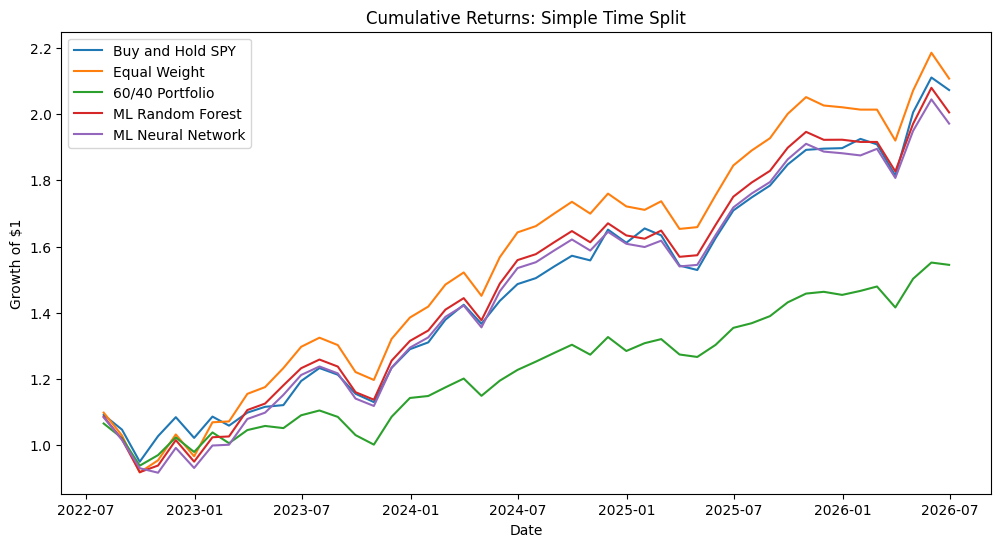

In [19]:
#plot cumulative returns
cumulative_returns_split = (1 + benchmark_returns_split).cumprod()

plt.figure(figsize=(12, 6))

for col in cumulative_returns_split.columns:
    plt.plot(cumulative_returns_split.index, cumulative_returns_split[col], label=col)

plt.title("Cumulative Returns: Simple Time Split")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

In [20]:
#feature importance
feature_importance_split = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_split

,Feature,Importance
0,return_1m,0.209318
4,volatility_6m,0.207601
1,return_3m,0.195849
3,volatility_3m,0.194229
2,return_6m,0.181182
5,trend_signal,0.011820


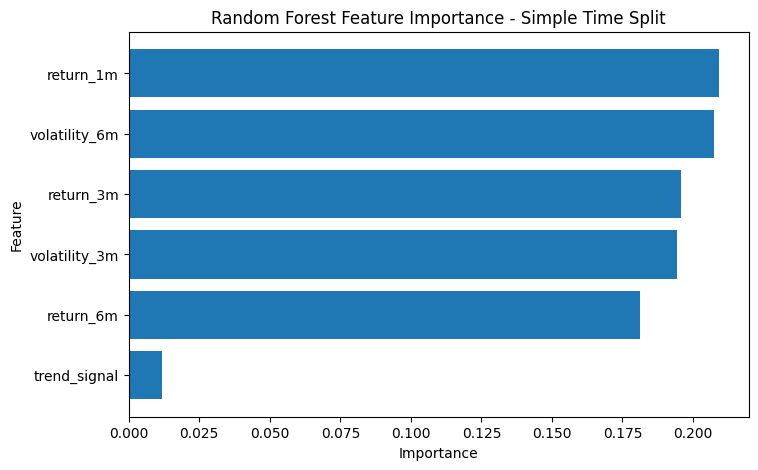

In [21]:
plt.figure(figsize=(8, 5))
plt.barh(feature_importance_split["Feature"], feature_importance_split["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance - Simple Time Split")
plt.gca().invert_yaxis()
plt.show()